# Model Statistics From Finished Predictions

This notebook evaluates the finished model outputs in:
- `Predictions/baseline.csv`
- `Predictions/timeseries.csv`
- `Predictions/mlp.csv`
- `Predictions/bayesian_predictions.csv`

Objective: predict point differentials

Secondary diagnostic: winner prediction accuracy

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# load finished predictions
baseline = pd.read_csv("Predictions/baseline.csv")
timeseries = pd.read_csv("Predictions/timeseries.csv")
mlp = pd.read_csv("Predictions/mlp.csv")
bayesian = pd.read_csv("Predictions/bayesian_predictions.csv")

models = {
    "baseline": baseline.copy(),
    "timeseries": timeseries.copy(),
    "mlp": mlp.copy(),
    "bayesian": bayesian.copy(),
}

for name, df in models.items():
    # add shared error columns
    if "ABS_ERROR" not in df.columns and {"PRED_MARGIN", "POINT_DIFFERENTIAL"}.issubset(df.columns):
        df["ABS_ERROR"] = (df["PRED_MARGIN"] - df["POINT_DIFFERENTIAL"]).abs()

    if "PRED_MARGIN" in df.columns and "POINT_DIFFERENTIAL" in df.columns:
        df["SQ_ERROR"] = (df["PRED_MARGIN"] - df["POINT_DIFFERENTIAL"]) ** 2
        pred_sign = np.sign(df["PRED_MARGIN"])

        true_sign = np.sign(df["POINT_DIFFERENTIAL"])

        valid = pred_sign != 0
        df["WINNER_CORRECT"] = np.where(valid, pred_sign == true_sign, np.nan)

    models[name] = df

In [9]:
def summarize_metrics(df):
    rows = []
    if "SPLIT" not in df.columns:
        return pd.DataFrame()

    # summarize each split separately
    for split, g in df.groupby("SPLIT"):
        rows.append({
            "split": split,
            "n_games": int(len(g)),
            "mae": float(g["ABS_ERROR"].mean()) if "ABS_ERROR" in g.columns else np.nan,
            "rmse": float(np.sqrt(g["SQ_ERROR"].mean())) if "SQ_ERROR" in g.columns else np.nan,
            "winner_accuracy": float(np.nanmean(g["WINNER_CORRECT"])) if "WINNER_CORRECT" in g.columns else np.nan,
        })

    out = pd.DataFrame(rows).sort_values("split").reset_index(drop=True)
    return out

summary = []
for name, df in models.items():
    s = summarize_metrics(df)
    if not s.empty:
        s.insert(0, "model", name)
        summary.append(s)

summary_table = pd.concat(summary, ignore_index=True)
summary_table

,model,split,n_games,mae,rmse,winner_accuracy
0,baseline,test,110,10.909576,13.429274,0.681818
1,baseline,train,529,10.499916,13.314801,0.657845
2,timeseries,test,188,10.985726,13.679665,0.712766
3,timeseries,train,879,9.999868,12.621348,0.684869
4,mlp,test,185,9.096996,11.410202,0.729730
5,mlp,train,876,8.848920,11.276616,0.715753
6,bayesian,test,201,10.033981,12.223755,0.716418
7,bayesian,train,928,8.562425,10.846399,0.727371


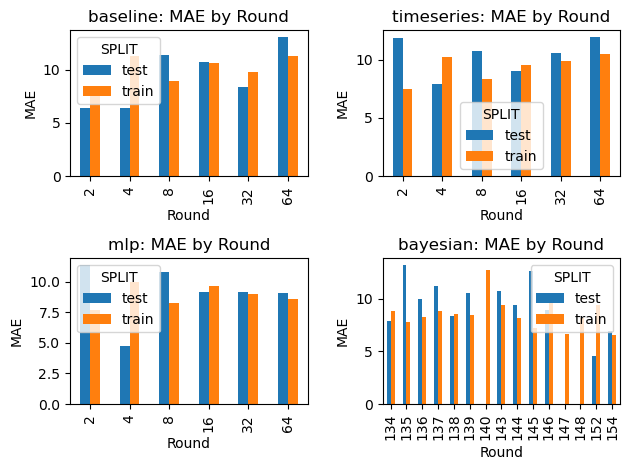

In [10]:
# mae by round for each model
model_names = list(models.keys())
fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

for i, name in enumerate(model_names):
    ax = axes[i]
    df = models[name]
    if {"CURRENT_ROUND", "SPLIT", "ABS_ERROR"}.issubset(df.columns):
        # average error by round and split
        round_mae = (
            df.groupby(["CURRENT_ROUND", "SPLIT"], as_index=False)
            .agg(MAE=("ABS_ERROR", "mean"))
            .sort_values("CURRENT_ROUND", ascending=False)
        )
        round_pivot = round_mae.pivot(index="CURRENT_ROUND", columns="SPLIT", values="MAE")
        round_pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"{name}: MAE by Round")
    ax.set_xlabel("Round")
    ax.set_ylabel("MAE")

plt.tight_layout()
plt.show()

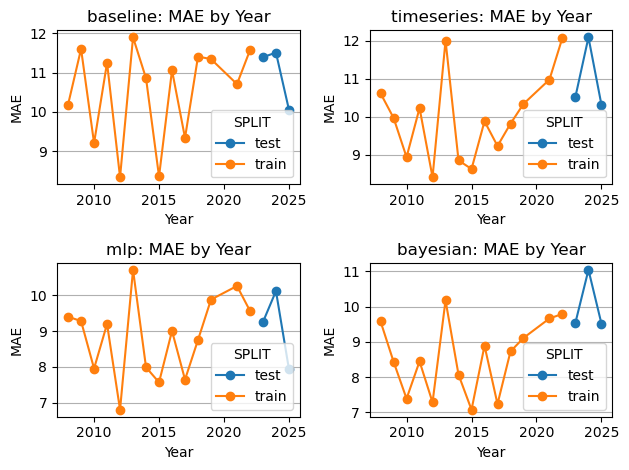

In [11]:
# mae by year for each model
model_names = list(models.keys())
fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

for i, name in enumerate(model_names):
    ax = axes[i]
    df = models[name]
    if {"YEAR", "SPLIT", "ABS_ERROR"}.issubset(df.columns):
        # average error by year and split
        year_mae = (
            df.groupby(["YEAR", "SPLIT"], as_index=False)
            .agg(MAE=("ABS_ERROR", "mean"))
            .sort_values("YEAR")
        )
        year_pivot = year_mae.pivot(index="YEAR", columns="SPLIT", values="MAE")
        year_pivot.plot(ax=ax, marker="o")
    ax.set_title(f"{name}: MAE by Year")
    ax.set_xlabel("Year")
    ax.set_ylabel("MAE")
    ax.grid(axis="y")

for j in range(len(model_names), len(axes)):
    # hide any empty panels
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()